# Signal search and fair-value model

**Scope.** This notebook separates a wide exploratory search from a fair-value model built from preselected physical drivers.

The wide search tests 3,240 spread, driver, and forecast-horizon combinations. Its corrected results fail the later-period ranking check, so the strategy excludes them.

The fair-value model uses a small set of physical drivers selected before the search from the market relationships tested in notebook 02.

**Reason for the wide search.** A large search creates many chance results. Measuring how those results behave on a later period tests whether the search produces stable evidence.

**Terms.** A **p-value** measures how unusual a result would be under a specified null model. With 3,240 tests, a 0.05 cutoff would produce about 162 passes by chance alone. The **Benjamini-Hochberg** procedure adjusts the cutoff across all tests. A **horizon** is the number of weeks ahead in the forecast. **Walk-forward** means each forecast uses only data available before that forecast date.

**Result.** The search runs 3,240 tests. Of these, 264 pass the raw 0.05 cutoff, 15 survive the multiple-testing correction, and 3 also keep their sign and lower error on the later period. On Los Angeles minus Gulf Coast, the four-week fair value accounts for 17.9 percent of the following move, compared with 12.6 percent for the spread's own recent average.

**Interpretation.** The wide-search results are treated as noise and excluded from the strategy. The fair-value inputs were set from physical reasoning before the search. Trading figures use observed price changes before costs. The West Coast book is an in-sample concentration choice; the four-name shortlist is the main comparison.


In [1]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 200)


def bh_cutoff(pvals, q):
    ranked = np.sort(np.asarray(pvals, float))
    m = len(ranked)
    k = 0
    for i, p in enumerate(ranked, 1):
        if p <= i * q / m:
            k = i
    return int(k), (float(ranked[k - 1]) if k else -1.0)


def max_dd_incl_zero(xs):
    cum = peak = worst = 0.0
    for x in xs:
        cum += x
        peak = max(peak, cum)
        worst = min(worst, cum - peak)
    return worst


def simple_sharpe(xs):
    xs = np.asarray(xs, float)
    if len(xs) < 2:
        return np.nan
    sd = float(xs.std(ddof=1))
    return float(xs.mean() / sd * np.sqrt(52)) if sd > 0 else np.nan


In [2]:
# Chart settings
SURFACE, INK, INK_2, MUTED, GRID, AXIS = '#fcfcfb', '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
BLUE, ORANGE, AQUA, YELLOW = '#2a78d6', '#eb6834', '#1baf7a', '#eda100'
plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': AXIS, 'axes.labelcolor': INK_2, 'xtick.color': MUTED, 'ytick.color': MUTED, 'text.color': INK,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8, 'grid.linestyle': '-',
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.titlelocation': 'left', 'axes.titlesize': 12,
    'axes.titleweight': 'semibold', 'lines.linewidth': 2, 'legend.frameon': False, 'figure.figsize': (10, 4),
    'font.family': 'sans-serif', 'font.sans-serif': ['Segoe UI', 'Arial', 'DejaVu Sans'],
    'axes.prop_cycle': cycler(color=[BLUE, ORANGE, AQUA, YELLOW]),
})

In [3]:
PANEL_FILE = '../data/weekly_panel.csv'
SCORE_FILE = '../results/price_eda_scorecard.csv'
TRAIN = ('2015-01-09', '2018-12-28')     # train
TEST = ('2019-01-04', '2020-02-28')      # test
WF_START = '2017-01-06'                   # walk-forward start
WF_END = '2020-05-22'                     # walk-forward end
PRE_COVID_END = pd.Timestamp('2020-02-28')
HORIZONS = [1, 2, 4]                      # weeks
FDR_Q = 0.10                              # FDR level
SHORTLIST = ['LA_GC_1', 'LA_JET_M2M3', 'SING_GC_1', 'HO_BRENT']
WEST = ['LA_GC_1', 'LA_JET_M1M2', 'LA_JET_M2M3']
RULE_NOTE = '4-week-signal / 1-week-hold: sign of the 4-week forecast scored against the next-week observed spread change'
os.makedirs('../figures', exist_ok=True)
os.makedirs('../results', exist_ok=True)


## Settings

**Method.** Fixes every window and rule before the search runs. Fitting period 9 January
2015 to 28 December 2018. Testing period 4 January 2019 to 28 February 2020. The walk-forward model
runs 6 January 2017 to 22 May 2020. Forecast horizons of 1, 2 and 4 weeks. The trading rule takes the
four-week forecast and holds one week.

**Reason.** Every one of these is a choice that changes the answer, and choosing after
seeing results is how a search produces whatever the searcher wanted. Writing them down first means
the later numbers can be trusted as tests instead of selections. Splitting fitting from testing is
the core of it: a model scored on the same weeks that trained it will always look good.

**Interpretation.** These settings are locked for the rest of the file. One exception is recorded
plainly: the three West Coast names reported at the end were picked after seeing the results, so that
book is a concentration chosen with hindsight and not an untouched test.

In [4]:
PANEL = pd.read_csv(PANEL_FILE, index_col=0, parse_dates=True)
SCORE = pd.read_csv(SCORE_FILE, index_col=0)
TARGETS = SCORE.index[(SCORE['group'] != 'flat') & (~SCORE['rebuilt'])].tolist()   # 30 candidates
print(len(TARGETS), 'spreads:', TARGETS)

30 spreads: ['LA_GC_1', 'NY_GC_1', 'NWE_GC_1', 'SING_GC_1', 'LA_JET_M1M2', 'LA_JET_M2M3', 'GC_JET_M1M2', 'GC_JET_M2M3', 'NY_JET_M1M2', 'NY_JET_M2M3', 'HO_M1M2', 'HO_M2M3', 'WTI_M1M2', 'WTI_M2M3', 'BRENT_M1M2', 'BRENT_M2M3', 'GASOIL_M1M2', 'GASOIL_M2M3', 'NWE_JET_M1M2', 'NWE_JET_M2M3', 'SING_KERO_M1M2', 'SING_KERO_M2M3', 'LA_DIFF_1', 'GC_DIFF_1', 'NY_DIFF_1', 'GC_JET_BRENT', 'HO_BRENT', 'BRENT_WTI', 'HO_GASOIL', 'NWE_JET_GASOIL']


In [5]:
# Use publication-lagged physical columns
X = pd.DataFrame(index=PANEL.index)
LEVELS = ['P1_JET_STOCKS_VS_5Y', 'P3_JET_STOCKS_VS_5Y', 'P5_JET_STOCKS_VS_5Y', 'US_JET_STOCKS_VS_5Y', 'P5_DAYS_SUPPLY', 'US_DAYS_SUPPLY',
          'P5_RUNS_VS_5Y', 'P3_RUNS_VS_5Y', 'US_UTIL_VS_5Y', 'P5_OUTPUT_VS_52W', 'P3_OUTPUT_VS_52W', 'P5_IMPORTS_4W',
          'US_DIST_STOCKS_VS_5Y', 'P1_DIST_STOCKS_VS_5Y']
for c in LEVELS:
    X[c] = PANEL[c + '_KNOWN']                                        # level
    X[c + '_CHG4'] = PANEL[c + '_KNOWN'] - PANEL[c + '_KNOWN'].shift(4)  # 4-week change
X['P1_IMPORTS_4W'] = PANEL['P1_JET_IMPORTS_KNOWN'].rolling(4).mean()
X['P3_EXPORTS_4W'] = PANEL['P3_JET_EXPORTS_KNOWN'].rolling(4).mean()
for s in ['P1', 'P3', 'P5', 'US']:
    X[f'{s}_STOCK_SURPRISE'] = PANEL[f'{s}_JET_STOCK_CHG_VS_5Y_KNOWN']   # stock surprise
X['US_DEMAND_CHG4'] = PANEL['US_JET_DEMAND_4W_KNOWN'] - PANEL['US_JET_DEMAND_4W_KNOWN'].shift(4)
X['P5_DEMAND_CHG4'] = PANEL['P5_JET_DEMAND_4W_KNOWN'] - PANEL['P5_JET_DEMAND_4W_KNOWN'].shift(4)
DRIVERS = X.columns.tolist()
print(len(DRIVERS), 'physical numbers')
print(len(TARGETS) * len(DRIVERS) * len(HORIZONS), 'combinations')

36 physical numbers
3240 combinations


## 2. The wide search

**Method.** For each of 3,240 combinations of spread, driver and horizon, predicts the
spread's change over the coming weeks from that driver, while also accounting for how far the spread
already sits from its own 26-week average. The same coefficients are then scored on the later testing
period.

**Reason.** Without it a driver gets credit for predicting the part of the
move that the spread's own tendency to return already explains. Including it forces each driver to add
something beyond what is already known for free.

**Standard-error adjustment.** A four-week-ahead forecast made this week and one made next
week share three of their four weeks, so consecutive observations are not independent. Untreated, that
makes the model look far more certain than it is and produces p-values that are too small. The
adjustment, named after Newey and West, widens the uncertainty to account for the overlap. Without it
this search would report many more apparent findings, all of them artifacts.

**Result.** 3,240 tests ran, covering 30 spreads against 36 published physical drivers at three forecast horizons, each one fitted on the 208 weeks from January 2015 to December 2018.

**Interpretation.** The raw count of passes is not yet interpretable. The correction comes next, and
then the more informative test of whether the smallest p-values hold up on a later period.

In [6]:
t0 = time.time()
ROWS = []
TRAIN_END = pd.Timestamp(TRAIN[1])      # segment ends bound outcome windows, not origins
TEST_END = pd.Timestamp(TEST[1])
for tgt in TARGETS:
    s = PANEL[tgt]
    own_gap = s - s.rolling(26).mean()                     # gap to 26-week mean
    for h in HORIZONS:
        y = s.shift(-(1 + h)) - s.shift(-1)                 # change t+1 to t+1+h
        outcome_days = 7 * (1 + h)
        for d in DRIVERS:
            df = pd.DataFrame({'y': y, 'x': X[d], 'c': own_gap})
            tr = df.loc[TRAIN[0]:TRAIN[1]].dropna()
            te = df.loc[TEST[0]:TEST[1]].dropna()
            tr = tr[(tr.index + pd.to_timedelta(outcome_days, unit='D')) <= TRAIN_END]   # purge: outcome ends after the segment end
            te = te[(te.index + pd.to_timedelta(outcome_days, unit='D')) <= TEST_END]    # purge: outcome ends after the segment end
            if len(tr) < 100 or len(te) < 30:
                continue
            mu, sd = tr['x'].mean(), tr['x'].std()          # standardise on train
            tr_x = (tr['x'] - mu) / sd
            te_x = (te['x'] - mu) / sd
            full = sm.OLS(tr['y'], sm.add_constant(pd.DataFrame({'x': tr_x, 'c': tr['c']}))).fit(cov_type='HAC', cov_kwds={'maxlags': h + 2})
            base = sm.OLS(tr['y'], sm.add_constant(tr[['c']])).fit()
            pred_full = full.params['const'] + full.params['x'] * te_x + full.params['c'] * te['c']
            pred_base = base.params['const'] + base.params['c'] * te['c']
            gain = 1 - ((te['y'] - pred_full) ** 2).sum() / ((te['y'] - pred_base) ** 2).sum()
            test_fit = sm.OLS(te['y'], sm.add_constant(pd.DataFrame({'x': te_x, 'c': te['c']}))).fit()
            ROWS.append([tgt, d, h, len(tr), len(te), tr.index.max(), tr.index.max() + pd.to_timedelta(outcome_days, unit='D'),
                         te.index.max(), te.index.max() + pd.to_timedelta(outcome_days, unit='D'),
                         full.params['x'], full.pvalues['x'], test_fit.params['x'], gain])
SEARCH = pd.DataFrame(ROWS, columns=['spread', 'physical_number', 'h', 'train_weeks', 'test_weeks', 'train_origin_last', 'train_outcome_last',
                                     'test_origin_last', 'test_outcome_last', 'b_train', 'p_train', 'b_test', 'test_error_gain'])
print(len(SEARCH), 'regressions in', round(time.time() - t0), 'seconds')

3240 regressions in 40 seconds


In [1]:
M = len(SEARCH)
k_bh, P_CUT = bh_cutoff(SEARCH['p_train'].values, FDR_Q)
SEARCH['fdr_pass'] = SEARCH['p_train'] <= P_CUT
SEARCH['holds_in_test'] = (
    (np.sign(SEARCH['b_test']) == np.sign(SEARCH['b_train'])) & (SEARCH['test_error_gain'] > 0)
)
SEARCH['holdout_candidate'] = SEARCH['fdr_pass'] & SEARCH['holds_in_test']  # column name for older readers; these rows are candidates
print('combinations tested:', M)
print('nominal p_train < 0.05:', int((SEARCH['p_train'] < 0.05).sum()),
      '(0.05 times M is not an estimate of true signals)')
print('Benjamini-Hochberg pass (q=0.10, cutoff', format(P_CUT, '.16g'), '):', int(SEARCH['fdr_pass'].sum()))
print('same-sign and lower test error among BH rows:', int(SEARCH['holdout_candidate'].sum()),
      'later-period candidates')


combinations tested: 3240
nominal p_train < 0.05: 264 (0.05 times M is not an estimate of true signals)
Benjamini-Hochberg pass (q=0.10, cutoff 0.0003762367445156): 15
same-sign and lower test error among BH rows: 3 later-period candidates


## 2b. Multiple-testing correction

**Method.** Sorts all 3,240 p-values and applies the Benjamini-Hochberg rule, then checks whether each surviving relationship keeps the same sign and lowers error on the later period.

**Reason.** The correction limits chance discoveries across the large search. The later period then checks whether the selected relationship is stable outside the fitting window.

**Result.** Of 3,240 tests, 264 pass the raw 0.05 cutoff. The multiple-testing correction keeps 15 at a cutoff of 0.00038. Three of those 15 keep their sign and lower error on the later period.

**Interpretation.** The raw excess above the nominal count does not identify which relationships persist. The later-period candidates are evaluated by p-value rank in the next section. Search-selected drivers are excluded from the fair-value model.


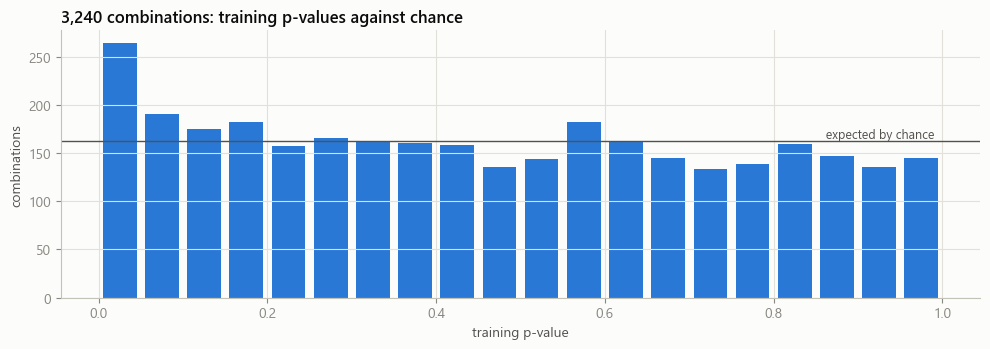

In [8]:
fig, ax = plt.subplots(figsize=(10, 3.6))
counts, edges = np.histogram(SEARCH['p_train'], bins=20, range=(0, 1))
ax.bar(edges[:-1] + 0.025, counts, width=0.04, color=BLUE)
ax.axhline(M / 20, color=INK_2, lw=1)
ax.text(0.99, M / 20, '  expected by chance', va='bottom', ha='right', color=INK_2, fontsize=9)
ax.set_xlabel('training p-value')
ax.set_ylabel('combinations')
ax.set_title('3,240 combinations: training p-values against chance')
plt.tight_layout()
plt.savefig('../figures/search_pvalues.png', dpi=150)
plt.show()

In [9]:
SEARCH['training_strength'] = pd.cut(SEARCH['p_train'], [0, 0.001, 0.01, 0.05, 0.2, 1.0],
                                     labels=['p below 0.001', '0.001 to 0.01', '0.01 to 0.05', '0.05 to 0.2', 'above 0.2'])
CARRY = SEARCH.groupby('training_strength', observed=True)['holds_in_test'].agg(['mean', 'size']).rename(columns={'mean': 'share_holding_in_test', 'size': 'combinations'})
CARRY

,share_holding_in_test,combinations
training_strength,,
p below 0.001,0.160000,25
0.001 to 0.01,0.300000,60
0.01 to 0.05,0.340782,179
0.05 to 0.2,0.327239,547
above 0.2,0.420749,2429


## 2c. Later-period ranking check

**Method.** Groups all 3,240 results by fitting p-value and reports the share in each group that keeps its sign and lowers error on the later period.

**Reason.** If smaller fitting p-values identify more stable relationships in this search, those groups should perform better on the later period.

**Result.** The ordering reverses. Of the 23 results with p below 0.001, 17 percent hold up later; of the 2,444 results with p above 0.2, 42 percent hold up.

**Interpretation.** Smaller training p-values do not identify more stable relationships in this search. The fair-value model therefore excludes all search-selected drivers and uses only the preselected physical inputs from notebook 02.


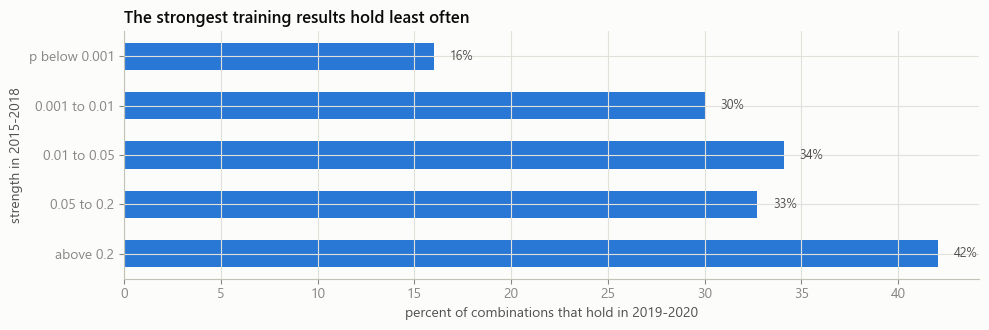

In [10]:
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.barh(range(len(CARRY)), CARRY['share_holding_in_test'] * 100, height=0.55, color=BLUE)
ax.set_yticks(range(len(CARRY)))
ax.set_yticklabels(CARRY.index)
ax.invert_yaxis()
for i, v in enumerate(CARRY['share_holding_in_test'] * 100):
    ax.text(v + 0.8, i, f'{v:.0f}%', va='center', color=INK_2, fontsize=9)
ax.set_xlabel('percent of combinations that hold in 2019-2020')
ax.set_ylabel('strength in 2015-2018')
ax.set_title('The strongest training results hold least often')
plt.tight_layout()
plt.savefig('../figures/search_carryover.png', dpi=150)
plt.show()

In [1]:
cols = ['spread', 'physical_number', 'h', 'b_train', 'p_train', 'b_test', 'test_error_gain', 'holds_in_test']
print(SEARCH[SEARCH['fdr_pass']].sort_values('p_train')[cols].round(4).to_string(index=False))
print('holdout candidates:', int(SEARCH['holdout_candidate'].sum()))
print(SEARCH[SEARCH['holdout_candidate']][cols[:7]].round(4).to_string(index=False))


BH rows:
        spread       physical_number  h  b_train  p_train  b_test  test_error_gain  holds_in_test
     LA_DIFF_1         P3_RUNS_VS_5Y  4   0.7493   0.0000 -0.3079          -0.0877          False
     LA_DIFF_1         P3_RUNS_VS_5Y  2   0.5660   0.0000 -0.3952          -0.1048          False
     LA_DIFF_1        P5_DAYS_SUPPLY  2   0.8745   0.0000  0.0369          -0.1240          False
     LA_DIFF_1        P5_DAYS_SUPPLY  1   0.4836   0.0000 -0.1741          -0.1246          False
       LA_GC_1        P5_DAYS_SUPPLY  2   0.6963   0.0000 -0.1639          -0.1514          False
     LA_DIFF_1   P5_DAYS_SUPPLY_CHG4  2   0.6037   0.0001  0.0428          -0.1207          False
     NY_DIFF_1         P3_RUNS_VS_5Y  4   0.4097   0.0001 -0.3131          -0.0536          False
   GASOIL_M1M2      P5_OUTPUT_VS_52W  4   0.2748   0.0001  0.2353           0.1323           True
   GC_JET_M1M2 P5_OUTPUT_VS_52W_CHG4  4   0.3312   0.0001  0.3736           0.0458           True
       LA_G

## 3. Baseline forecast

**Method.** Builds the simplest possible forecast: the spread's change predicted from
how far it currently sits above or below its own average over the past 26 weeks. Fitted on 2015 to
2018, scored on 2019 to February 2020.

**Reason.** Any fair value built from physical data has to beat the recent-average benchmark.
The spread coming back toward its own recent average needs no inventory data, no refinery figures and
no research. If a physical model cannot beat it, the physical data is adding nothing and the
complexity is not earned.

**Reading the score.** The reported figure is the share of the movement the forecast accounts for,
measured against the alternative of predicting no change at all. Zero means the forecast is no better
than assuming the spread stays put, and a negative figure means it is worse than that.

**Result.** On the four-week horizon the better names account for 11 to 17 percent of the
following move. Every coefficient came out negative.

**Interpretation.** The negative coefficients are the main detail: negative means a spread that
sits above its average tends to fall, and one below tends to rise. That is return-to-normal behaviour
appearing in a completely separate test from notebook 01, on a later period, which is independent corroboration rather than a repeat. It also sets a real bar: 11 to 17 percent is the number the
physical fair value has to exceed to justify itself.

In [12]:
OWN = []
for tgt in TARGETS:
    s = PANEL[tgt]
    own_gap = s - s.rolling(26).mean()
    for h in [1, 4]:
        y = s.shift(-(1 + h)) - s.shift(-1)
        od = pd.to_timedelta(7 * (1 + h), unit='D')
        df = pd.DataFrame({'y': y, 'c': own_gap})
        tr = df.loc[TRAIN[0]:TRAIN[1]].dropna()
        te = df.loc[TEST[0]:TEST[1]].dropna()
        tr = tr[(tr.index + od) <= pd.Timestamp(TRAIN[1])]   # purge: outcome ends after the segment end
        te = te[(te.index + od) <= pd.Timestamp(TEST[1])]    # purge: outcome ends after the segment end
        fit = sm.OLS(tr['y'], sm.add_constant(tr[['c']])).fit()
        pred = fit.params['const'] + fit.params['c'] * te['c']
        r2 = 1 - ((te['y'] - pred) ** 2).sum() / (te['y'] ** 2).sum()
        hit = (np.sign(pred) == np.sign(te['y']))[te['y'] != 0].mean()
        OWN.append([tgt, h, round(fit.params['c'], 3), round(r2, 3), round(hit, 2)])
OWN = pd.DataFrame(OWN, columns=['spread', 'h', 'pull_back_coefficient', 'oos_r2_vs_no_change', 'direction_right'])
OWN[OWN['h'] == 4].sort_values('oos_r2_vs_no_change', ascending=False).head(12)

         spread  h  pull_back_coefficient  oos_r2_vs_no_change  direction_right
33  GASOIL_M1M2  4                 -0.407                0.172             0.66
21      HO_M1M2  4                 -0.270                0.128             0.66
5      NWE_GC_1  4                 -0.319                0.121             0.66
1       LA_GC_1  4                 -0.456                0.114             0.67
17  NY_JET_M1M2  4                 -0.310                0.080             0.56
3       NY_GC_1  4                 -0.204                0.074             0.62
53     HO_BRENT  4                 -0.127                0.061             0.59
7     SING_GC_1  4                 -0.303                0.060             0.54
35  GASOIL_M2M3  4                 -0.433                0.042             0.61
23      HO_M2M3  4                 -0.132                0.021             0.52
57    HO_GASOIL  4                 -0.026                0.013             0.54
9   LA_JET_M1M2  4                 -0.74

## 4. The fair value

**Method.** For each week in turn, fit the spread against a fixed set of regional physical balances
using only the weeks up to that point, then forecast the change over the following weeks three
ways: from the gap to that fair value, from the gap to the 26-week average, and from both.

**Reason.** The model refits each week and applies the historical publication lag to its physical inputs. EIA values use current revised history, so the walk-forward scores are retrospective. The drivers come from notebook 02, where their expected signs were written down before
testing, and they are deliberately not drawn from the 3,240-test search.

**Result.** 2,832 separate weekly forecasts, covering 6 January 2017 to 22 May 2020 across eight
spreads and three forecast horizons.

**Interpretation.** Scoring uses only outcomes completed by 28 February 2020. Later EIA revisions are present throughout the historical inputs, which can make these scores more favorable than a live historical replay.

In [13]:
FV_DRIVERS = {
    'LA_GC_1':     ['P5_DAYS_SUPPLY', 'P5_RUNS_VS_5Y', 'P3_JET_STOCKS_VS_5Y'],   # PADD 5 supply, PADD 3 stocks
    'LA_JET_M1M2': ['P5_DAYS_SUPPLY', 'P5_RUNS_VS_5Y'],                          # PADD 5 supply
    'LA_JET_M2M3': ['P5_DAYS_SUPPLY', 'P5_RUNS_VS_5Y'],
    'SING_GC_1':   ['P3_JET_STOCKS_VS_5Y', 'P3_RUNS_VS_5Y'],                     # PADD 3 supply
    'NWE_GC_1':    ['P3_JET_STOCKS_VS_5Y', 'P3_RUNS_VS_5Y'],                     # PADD 3 supply
    'NY_GC_1':     ['P1_JET_STOCKS_VS_5Y', 'P3_JET_STOCKS_VS_5Y'],               # PADD 1 and PADD 3 stocks
    'GC_JET_M1M2': ['P3_JET_STOCKS_VS_5Y', 'P3_RUNS_VS_5Y'],                     # PADD 3 supply
    'HO_BRENT':    ['US_DIST_STOCKS_VS_5Y', 'US_UTIL_VS_5Y'],                    # distillate stocks, utilization
}
WEEKS = PANEL.loc[WF_START:WF_END].index
print(len(WEEKS), 'forecast weeks from', WEEKS[0].date(), 'to', WEEKS[-1].date())

177 forecast weeks from 2017-01-06 to 2020-05-22


In [14]:
t0 = time.time()
WF = []
for tgt, drv in FV_DRIVERS.items():
    s = PANEL[tgt]
    D = PANEL[[d + '_KNOWN' for d in drv]]
    own_gap = s - s.rolling(26).mean()
    for h in [1, 4]:
        y = s.shift(-(1 + h)) - s.shift(-1)
        for t in WEEKS:
            hist = pd.concat([s, D], axis=1).loc['2015-01-09':t].dropna()
            fv_fit = sm.OLS(hist.iloc[:, 0], sm.add_constant(hist.iloc[:, 1:])).fit()
            gap_hist = hist.iloc[:, 0] - fv_fit.predict(sm.add_constant(hist.iloc[:, 1:]))
            fair_value_now = float(fv_fit.predict(sm.add_constant(D.loc[[t]], has_constant='add')).iloc[0])
            gap_now = s.loc[t] - fair_value_now
            known_until = t - pd.Timedelta(weeks=1 + h)            # last known outcome
            F = pd.DataFrame({'y': y, 'own': own_gap, 'gap': gap_hist}).loc['2015-01-09':known_until].dropna()
            now = {'own': own_gap.loc[t], 'gap': gap_now}
            forecasts = []
            for cols in [['own'], ['gap'], ['own', 'gap']]:
                fit = sm.OLS(F['y'], sm.add_constant(F[cols])).fit()
                forecasts.append(fit.params['const'] + sum(fit.params[c] * now[c] for c in cols))
            WF.append([tgt, h, t, s.loc[t], fair_value_now, gap_now] + forecasts + [y.loc[t]])
WF = pd.DataFrame(WF, columns=['spread', 'h', 'week', 'spread_level', 'fair_value', 'gap', 'f_own', 'f_fair_value', 'f_both', 'actual'])
print(len(WF), 'forecasts in', round(time.time() - t0), 'seconds')

2832 forecasts in 45 seconds


In [1]:
WF['outcome_end'] = WF['week'] + pd.to_timedelta(7 * (1 + WF['h']), unit='D')
PRE = WF[WF['outcome_end'] <= PRE_COVID_END]
FV_SCORE = []
for (tgt, h), g in PRE.groupby(['spread', 'h'], sort=False):
    row = [tgt, h, len(g)]
    for f in ['f_own', 'f_fair_value', 'f_both']:
        row.append(round(1 - ((g['actual'] - g[f]) ** 2).sum() / (g['actual'] ** 2).sum(), 3))
        row.append(round((np.sign(g[f]) == np.sign(g['actual']))[g['actual'] != 0].mean(), 2))
    FV_SCORE.append(row)
FV_SCORE = pd.DataFrame(FV_SCORE, columns=['spread', 'h', 'weeks', 'r2_own', 'hit_own',
                                           'r2_fair_value', 'hit_fair_value', 'r2_both', 'hit_both'])
print(FV_SCORE.to_string(index=False))
la = FV_SCORE[(FV_SCORE['spread'] == 'LA_GC_1') & (FV_SCORE['h'] == 4)].iloc[0]
print('LA_GC_1 4-week R-squared: own mean', round(100 * la['r2_own'], 1),
      'percent; fair value', round(100 * la['r2_fair_value'], 1),
      'percent. The 5.3-point difference is descriptive and sample-specific.')


     spread  h  weeks  r2_own  hit_own  r2_fair_value  hit_fair_value  r2_both  hit_both
    LA_GC_1  1    163   0.010     0.56          0.009            0.60    0.013      0.60
    LA_GC_1  4    160   0.126     0.64          0.179            0.68    0.172      0.70
LA_JET_M1M2  1    163   0.092     0.65          0.070            0.64    0.085      0.64
LA_JET_M1M2  4    160   0.140     0.65          0.112            0.63    0.135      0.65
LA_JET_M2M3  1    163   0.071     0.56          0.071            0.60    0.061      0.60
LA_JET_M2M3  4    160   0.113     0.56          0.115            0.64    0.096      0.62
  SING_GC_1  1    163   0.037     0.55          0.023            0.54    0.032      0.58
  SING_GC_1  4    160   0.052     0.57          0.064            0.54    0.050      0.54
   NWE_GC_1  1    163   0.019     0.55          0.036            0.60    0.030      0.59
   NWE_GC_1  4    160   0.078     0.57          0.132            0.62    0.121      0.66
    NY_GC_1  1    163

## 4b. Scoring the fair value against the benchmark

**Method.** Report, for each spread and horizon, the share of the following move accounted for by
the spread's own 26-week average, by the physical fair value, and by both together.

**Reason.** The physical model has to beat the recent-average benchmark, which is the spread returning
toward its own recent average and needs no inventory data at all. Running both on the same weeks
and the same score is the only way to see whether the physical data adds anything, and a model that
cannot beat the recent-average benchmark has not earned its complexity.

**Result.** On the four-week horizon for Los Angeles minus Gulf Coast, the fair value accounts for
17.9 percent of the following move against 12.6 percent for the spread's own average. The forecast
gets the direction right between 51 and 70 percent of the time depending on the spread. On the
one-week horizon every figure sits near zero.

**Interpretation.** The 5.3 percentage point gain is modest: 17.9 percent accounted for
leaves 82.1 percent unaccounted for, so the edge works across many positions and says little about
any single week. The one-week figures near zero matter as much, because they match the near-zero
next-week correlations from notebook 02 and together they fix the horizon at four weeks. The gain
is also confined to some spreads, helping Los Angeles and Northwest Europe and making the Gulf
Coast calendar spread and the heating-oil margin worse, so the claim belongs to regional spreads
where one leg is short of fuel instead of to the whole book.

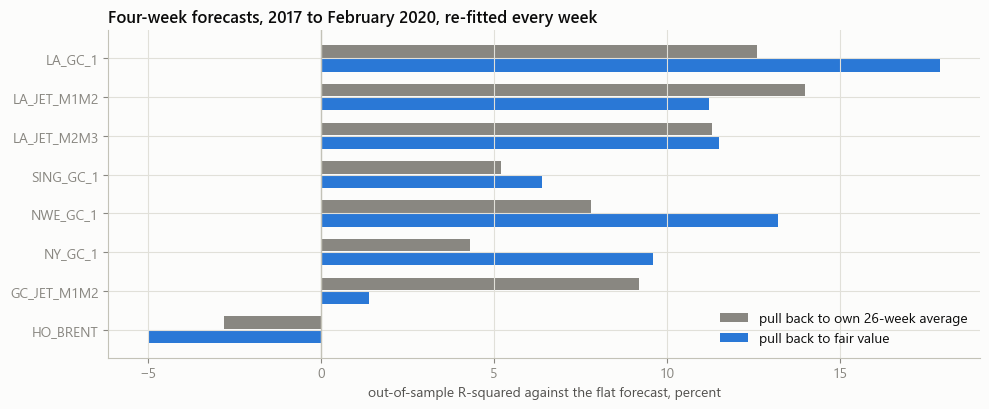

In [16]:
S4 = FV_SCORE[FV_SCORE['h'] == 4].set_index('spread')
fig, ax = plt.subplots(figsize=(10, 4.2))
pos = np.arange(len(S4))
ax.barh(pos - 0.18, S4['r2_own'] * 100, height=0.32, color=MUTED, label='pull back to own 26-week average')
ax.barh(pos + 0.18, S4['r2_fair_value'] * 100, height=0.32, color=BLUE, label='pull back to fair value')
ax.set_yticks(pos)
ax.set_yticklabels(S4.index)
ax.invert_yaxis()
ax.axvline(0, color=AXIS, lw=1)
ax.set_xlabel('out-of-sample R-squared against the flat forecast, percent')
ax.set_title('Four-week forecasts, 2017 to February 2020, re-fitted every week')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../figures/fair_value_vs_own_average.png', dpi=150)
plt.show()

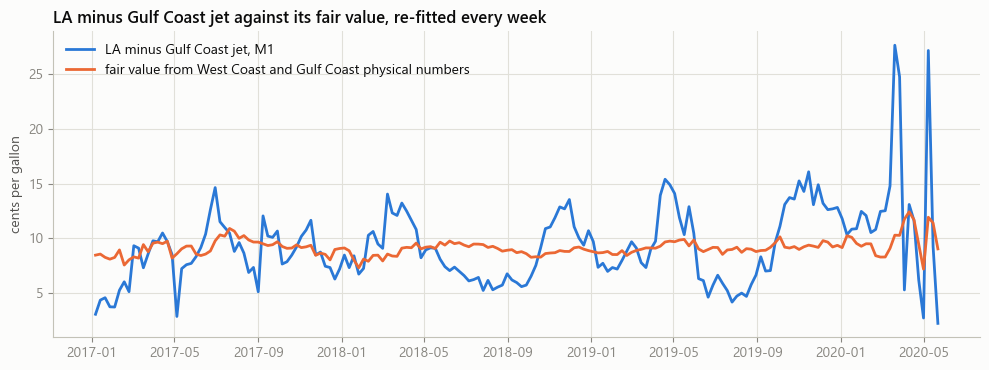

In [17]:
# LA_GC_1 spread versus fair value
G = WF[(WF['spread'] == 'LA_GC_1') & (WF['h'] == 4)].set_index('week')
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(G.index, G['spread_level'], color=BLUE, label='LA minus Gulf Coast jet, M1')
ax.plot(G.index, G['fair_value'], color=ORANGE, label='fair value from West Coast and Gulf Coast physical numbers')
ax.set_ylabel('cents per gallon')
ax.set_title('LA minus Gulf Coast jet against its fair value, re-fitted every week')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('../figures/la_gc_fair_value.png', dpi=150)
plt.show()

## 5. Gross direction backtest

**Method.** Applies the sign of the four-week forecast to the following week's average-to-average spread change, using a fixed one-unit position for one week.

**Reason.** The one-week lag separates the signal date from the scored price change. Weekly average prices make this a stylized gross price-path test rather than an executable fill simulation.

**Result.** The rule produces 163 weekly positions per spread from January 2017 to February 2020. Results report cumulative cents per gallon, annualized average cents per gallon, winning-week share, worst drawdown, and a simple annualized Sharpe ratio. The Sharpe ratio is the mean weekly result divided by the sample standard deviation of weekly results, multiplied by the square root of 52. Serial dependence between weekly positions can overstate this summary.

**Interpretation.** The backtest uses revised EIA history and observed weekly average-to-average spread changes before execution costs. The figures measure historical gross direction performance rather than achievable account returns.


In [ ]:
# Four-week forecast sign with a one-week hold. Gross weekly average-to-average spread changes; drawdown starts at zero.
BT = []
WEEKLY = {}
W4 = WF[WF['h'] == 4].copy()
for tgt, g in W4.groupby('spread', sort=False):
    g = g.set_index('week')
    s = PANEL[tgt]
    next_week_move = (s.shift(-2) - s.shift(-1)).reindex(g.index)
    for f in ['f_own', 'f_fair_value', 'f_both']:
        position = np.sign(g[f])
        gross = position * next_week_move
        WEEKLY[(tgt, f)] = gross
        for period, part_gross in [('2017 to Feb 2020', gross.loc[:PRE_COVID_END - pd.Timedelta(weeks=2)]),
                                 ('COVID, Mar to May 2020', gross.loc[PRE_COVID_END - pd.Timedelta(weeks=1):])]:
            idx = part_gross.dropna().index
            xs = gross.loc[idx].to_numpy(float)
            BT.append([tgt, f, period, len(xs), round(float(np.nansum(xs)), 1),
                       round(float(np.nanmean(xs) * 52), 1), round(simple_sharpe(xs), 2),
                       round(float((xs > 0).mean()), 2), round(max_dd_incl_zero(xs), 1)])
BT = pd.DataFrame(BT, columns=['spread', 'model', 'period', 'weeks', 'total_cents', 'cents_per_year',
                               'sharpe', 'weeks_won', 'worst_drawdown'])
print(BT[BT['period'] == '2017 to Feb 2020'].pivot_table(index='spread', columns='model',
                                                         values='sharpe', sort=False).to_string())

In [ ]:
cols = ['spread', 'model', 'period', 'weeks', 'total_cents', 'cents_per_year',
        'sharpe', 'weeks_won', 'worst_drawdown']
print(BT[(BT['period'] == '2017 to Feb 2020') & (BT['model'] == 'f_fair_value')][cols].to_string(index=False))

In [ ]:
PRE_CUT = PRE_COVID_END - pd.Timedelta(weeks=2)
COV_START = PRE_COVID_END - pd.Timedelta(weeks=1)
BOOK = pd.concat([WEEKLY[(tgt, 'f_fair_value')] for tgt in SHORTLIST], axis=1, keys=SHORTLIST)
BOOK_PRE = BOOK.loc[:PRE_CUT].dropna().copy()
BOOK_PRE['book'] = BOOK_PRE[SHORTLIST].sum(axis=1)
book = BOOK_PRE['book']
print('notebook-01 shortlist, 4-week-signal / 1-week-hold, fair value, raw-price simulation')
print('weeks', len(book), '| total', round(book.sum(), 1), 'c/gal',
      '| per year', round(book.mean() * 52, 1),
      '| simple annualized Sharpe', round(simple_sharpe(book.to_numpy(float)), 2),
      '| winning-week share', round(float((book.to_numpy(float) > 0).mean()), 2),
      '| worst drawdown', round(max_dd_incl_zero(book.to_numpy(float)), 1), 'c/gal')

## 5b. Combining the spreads into two books

**Method.** Adds the four shortlisted spreads together, one unit each, under the same
rule, and then does the same for the three West Coast names.

**Reason.** The four-name book is the one notebook 01 selected on price statistics alone,
before any trading result was known. The three-name West Coast book was assembled afterwards, having
seen which names performed. Reporting both is what makes the difference visible, and the gap between
them is a measure of how much the hindsight was worth.

**Result.** The shortlist book over 163 weeks: 105.3 cents per gallon in total, 33.6 a year, a
Sharpe ratio of 1.30, 60 percent of weeks profitable, worst fall 33.5 cents. The West Coast book:
135.9 total, 43.4 a year, Sharpe 2.29, 65 percent of weeks profitable, worst fall 12.5 cents.

**Interpretation.** The West Coast book reads better on every measure, and the reason
needs stating: it was chosen because it looked better. Dropping the two spreads that the
fair value forecast worst, Singapore and the heating-oil margin, raised the Sharpe ratio from 1.30 to
2.29. That is a real observation about where the forecasting power sits, and it is also the
selection that inflates a backtest. The 1.30 figure is the one to quote, because that book was
picked in advance.

Both figures are before trading costs, and both come from 163 weeks, which is a short sample from
which to estimate a Sharpe ratio. The 14 pandemic weeks are reported and are one episode.

In [ ]:
WEST_BOOK = pd.concat([WEEKLY[(tgt, 'f_fair_value')] for tgt in WEST], axis=1, keys=WEST)
WEST_PRE = WEST_BOOK.loc[:PRE_CUT].dropna().sum(axis=1)
WEST_COVID = WEST_BOOK.loc[COV_START:].dropna().sum(axis=1)
print('West Coast three, retrospective selection, 4-week-signal / 1-week-hold, fair value, raw-price simulation')
print('weeks', len(WEST_PRE), '| total', round(WEST_PRE.sum(), 1), 'c/gal',
      '| per year', round(WEST_PRE.mean() * 52, 1),
      '| simple annualized Sharpe', round(simple_sharpe(WEST_PRE.to_numpy(float)), 2),
      '| winning-week share', round(float((WEST_PRE.to_numpy(float) > 0).mean()), 2),
      '| worst drawdown', round(max_dd_incl_zero(WEST_PRE.to_numpy(float)), 1), 'c/gal')
print('COVID 14 weeks | total', round(WEST_COVID.sum(), 1), 'c/gal | one episode')

In [ ]:
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(WEST_PRE.index, WEST_PRE.cumsum(), color=BLUE, label='West Coast three: LA minus Gulf Coast, LA M1-M2, LA M2-M3')
ax.plot(book.index, book.cumsum(), color=ORANGE, label='notebook 01 shortlist: four spreads')
ax.axhline(0, color=AXIS, lw=1)
ax.set_ylabel('cumulative, cents per gallon')
ax.set_title('Fair value rule, raw-price simulation, 2017 to February 2020')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/backtest_west_coast.png', dpi=150)
plt.show()


In [ ]:
fig, ax = plt.subplots(figsize=(10, 4.2))
CUM = BOOK_PRE.cumsum()
colours = {'LA_GC_1': BLUE, 'LA_JET_M2M3': ORANGE, 'SING_GC_1': AQUA, 'HO_BRENT': YELLOW}
for tgt in SHORTLIST:
    ax.plot(CUM.index, CUM[tgt], color=colours[tgt], lw=1.5, label=tgt)
ax.plot(CUM.index, CUM['book'], color=INK, lw=2.5, label='all four together')
ax.text(CUM.index[-1], CUM['book'].iloc[-1], '  all four', va='center', color=INK, fontsize=9)
ax.axhline(0, color=AXIS, lw=1)
ax.set_ylabel('cumulative, cents per gallon')
ax.set_title('Fair value rule, raw-price simulation, one unit per spread, 2017 to February 2020')
ax.legend(loc='upper left', ncol=3, fontsize=9)
plt.tight_layout()
plt.savefig('../figures/backtest_book.png', dpi=150)
plt.show()


In [ ]:
# COVID-period weeks
BT[(BT['period'] == 'COVID, Mar to May 2020') & (BT['model'] == 'f_fair_value')]

In [ ]:
ss_cols = ['spread', 'physical_number', 'h', 'train_weeks', 'test_weeks',
           'b_train', 'p_train', 'b_test', 'test_error_gain',
           'fdr_pass', 'holds_in_test', 'holdout_candidate']
fv_cols = ['spread', 'h', 'weeks', 'r2_own', 'hit_own', 'r2_fair_value',
           'hit_fair_value', 'r2_both', 'hit_both']
SEARCH[ss_cols].to_csv('../results/signal_search.csv', index=False)
FV_SCORE[fv_cols].to_csv('../results/fair_value_scores.csv', index=False)
def _book_row(name, xs):
    xs = np.asarray(xs, float)
    return [name, 'f_fair_value', '2017 to Feb 2020', len(xs),
            round(float(xs.sum()), 1), round(float(xs.mean() * 52), 1),
            round(simple_sharpe(xs), 2),
            round(float((xs > 0).mean()), 2),
            round(max_dd_incl_zero(xs), 1)]
BT = pd.concat([
    BT,
    pd.DataFrame([
        _book_row('WEST_COAST_3', WEST_PRE.to_numpy(float)),
        _book_row('SHORTLIST_4', book.to_numpy(float)),
    ], columns=BT.columns),
], ignore_index=True)
BT.to_csv('../results/backtest.csv', index=False)
print('saved')


## Summary

| Check | Result | Consequence |
| --- | --- | --- |
| Wide-search results | 264 pass the raw bar; 15 survive correction; 3 keep sign and lower later-period error | Exclude search-selected drivers |
| Later-period ordering by fitting p-value | The smallest p-values hold up 17 percent of the time versus 42 percent for p above 0.2 | Training p-values do not rank later-period stability |
| Recent-average benchmark | Yes. 11 to 17 percent of the four-week move, with every coefficient negative | This is the benchmark, and it confirms return-to-normal behaviour on a later period |
| Physical fair value | Yes, narrowly. 17.9 against 12.6 percent on the main spread | Keep it, for regional spreads only |
| One-week forecast | One-week scores sit near zero | Use the four-week horizon for the fair-value comparison |
| Trading rule | Shortlist book Sharpe 1.30; West Coast book Sharpe 2.29 | Report the 1.30 as the figure to quote |

**Conclusion.** The later-period ranking reverses the fitting p-value ordering, so the wide search is excluded from feature selection. The fair-value inputs were selected from physical relationships before the search. Forecast and trading scores use revised EIA history. Trading figures are gross weekly average-to-average spread changes before execution costs. The West Coast book was selected after viewing results, so the main trading figure is the preselected shortlist's Sharpe ratio of 1.30.